In [2]:
# Data cleaning process 
# On Titanic Dataset

In [4]:
import numpy as np
import pandas as pd

In [8]:
df=pd.read_csv('Titanic-Dataset.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
df.shape

(891, 12)

In [18]:
df.isna().sum().sum()

866

In [20]:
# Check for Duplicate Rows

df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [22]:
# Separating columns to categorical and numerical data

cat_col=[col for col in df.columns if df[col].dtype=='object']
num_col=[col for col in df.columns if df[col].dtype!='object']

In [24]:
cat_col

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [26]:
num_col

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

In [32]:
# checking unique values in categorical col

df[cat_col].nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

In [42]:
# Calculating missing value percentage in the DataFrame

round(((df.isna().sum())/df.shape[0]*100),2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

In [44]:
# Drop Irrelevant or Data-Heavy Missing Columns
# df.drop(columns=[]): Drops specified columns from the DataFrame.
# df.dropna(subset=[]): Removes rows where specified columns have missing values.
# fillna(): Fills missing values with specified value (e.g., mean).

In [62]:
df1=df.drop(columns=['Name','Ticket','Cabin'])
df1.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [66]:
df1['Embarked'].isna().sum()

2

In [70]:
df1.dropna(subset=['Embarked'],inplace=True)  # Removes all the rows with null values
df1['Embarked'].isna().sum()

0

In [72]:
df1['Age'].isna().sum()

177

In [78]:
df1['Age']=df1['Age'].fillna(df1['Age'].mean())
df1['Age'].isna().sum()

0

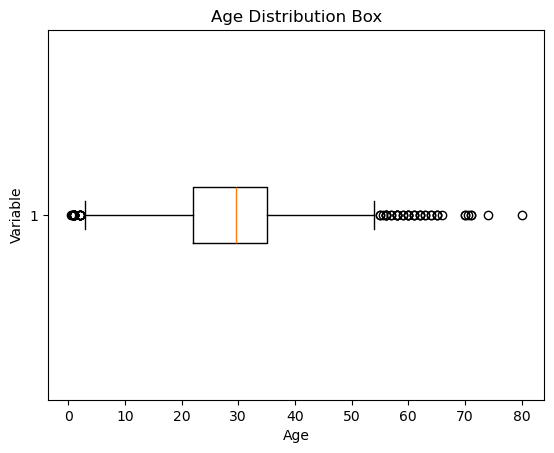

In [84]:
# Detecting Outliers

import matplotlib.pyplot as plt

plt.boxplot(df1['Age'],vert=False) # vert determines wheather we need the plot in vertical or not
plt.ylabel("Variable")
plt.xlabel("Age")
plt.title("Age Distribution Box")
plt.show()

In [86]:
# Calculating Outlier Boundaries to Remove Them

In [102]:
mean=df1["Age"].mean()
std=df1['Age'].std()

lower_bound=mean-2*std
upper_bound=mean+2*std

df2= df1[(df1['Age']>=lower_bound) & (df1['Age']<=upper_bound)] # Denotes all the rows that are within the boundaries in bool

df2

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.000000,1,0,7.2500,S
1,2,1,1,female,38.000000,1,0,71.2833,C
2,3,1,3,female,26.000000,0,0,7.9250,S
3,4,1,1,female,35.000000,1,0,53.1000,S
4,5,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.000000,0,0,13.0000,S
887,888,1,1,female,19.000000,0,0,30.0000,S
888,889,0,3,female,29.642093,1,2,23.4500,S
889,890,1,1,male,26.000000,0,0,30.0000,C


In [104]:
df3=df2.fillna(df2['Age'].mean())
df3.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [108]:
mean=df3['Age'].mean()
std=df3['Age'].std()

lower_bound=mean-2*std
upper_bound=mean+2*std

print(f"Lower Bound : {lower_bound}")
print(f"Upper Bound : {upper_bound}")

Lower Bound : 8.978989004171481
Upper Bound : 49.30395961288911


In [112]:
df4=df3[(df3['Age']>=lower_bound) & (df3['Age']<=upper_bound)]
df4

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.000000,1,0,7.2500,S
1,2,1,1,female,38.000000,1,0,71.2833,C
2,3,1,3,female,26.000000,0,0,7.9250,S
3,4,1,1,female,35.000000,1,0,53.1000,S
4,5,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.000000,0,0,13.0000,S
887,888,1,1,female,19.000000,0,0,30.0000,S
888,889,0,3,female,29.642093,1,2,23.4500,S
889,890,1,1,male,26.000000,0,0,30.0000,C


Data validation and verification involve ensuring that the data is accurate and consistent by comparing it with external sources or expert knowledge. 

For the machine learning prediction we separate independent and target features
Here we will consider 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', and 'Embarked' as independent features.
Survived as target variables because PassengerId will not affect the survival rate

In [119]:
X = df3[['Pclass','Sex','Age', 'SibSp','Parch','Fare','Embarked']]
Y = df3['Survived']

## Data formatting

Data formatting involves converting the data into a standard format or structure that can be easily processed by the algorithms or models used for analysis. Here we will discuss commonly used data formatting techniques i.e. Scaling and Normalization.

1. Min-Max Scaling: Scaling involves transforming the values of features to a specific range. Min-Max scaling rescales the values to a specified range, typically between 0 and 1. It preserves the original distribution and ensures that the minimum value maps to 0 and the maximum value maps to 1.

In [123]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler(feature_range=(0,1))

num_col1=[col for col in X if X[col].dtype!='object']

x1=X
x1.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [125]:
x1[num_col1]=scaler.fit_transform(x1[num_col1])
x1.head()

C:\Users\vilas\AppData\Local\Temp\ipykernel_16376\1445017547.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x1[num_col1]=scaler.fit_transform(x1[num_col1])


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,male,0.349515,0.125,0.0,0.014151,S
1,0.0,female,0.660194,0.125,0.0,0.139136,C
2,1.0,female,0.427184,0.000,0.0,0.015469,S
3,0.0,female,0.601942,0.125,0.0,0.103644,S
4,1.0,male,0.601942,0.000,0.0,0.015713,S
